In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
plt.style.use("seaborn-v0_8-darkgrid") # Usar os estilos nativos do Matplotlib, tema escuro
sns.set_theme(style="darkgrid")


### K-Means Clustering

In [6]:
from sklearn.datasets import make_blobs

In [8]:
data = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=[2, 1, 1, 2], random_state=101)
# (n_samples=200 (200 pontos), n_features=2(x 1 e x2 = 2 features), centers=4(4 classes diferentes), cluster_std=[2, 1, 1, 2](formas dos meus centers), random_state=101

In [16]:
#### visualizar os dados, x1 e x2
#### 200 linhas
data


(array([[-6.71419265e+00,  1.03932125e+01],
        [ 4.90728366e+00,  5.85747409e+00],
        [-4.54340700e-01,  3.46993806e+00],
        [ 2.85067973e+00,  8.28075279e+00],
        [ 4.47750967e+00,  6.97215388e+00],
        [-1.02351670e+01, -6.31601883e+00],
        [ 2.77693736e+00,  8.39388742e+00],
        [-1.94531663e+00,  1.41408470e+00],
        [ 2.29641395e+00,  7.54884427e+00],
        [-1.53850188e+00,  3.32346476e+00],
        [-6.44379397e+00,  9.87426599e+00],
        [-1.36818141e+00,  2.62528244e+00],
        [ 3.25966685e+00,  7.36381102e+00],
        [ 2.97607330e+00,  5.95782750e+00],
        [-5.43264879e+00,  9.83460048e+00],
        [-6.66235492e-01, -9.47876647e-02],
        [ 4.96544332e+00,  6.23003890e+00],
        [-2.60705549e+00,  4.25161021e-01],
        [-9.82160444e+00, -4.82608993e+00],
        [-4.61639859e+00,  1.17831014e+01],
        [-9.97777536e+00, -6.07283992e+00],
        [ 7.02221598e-01, -5.23385577e-02],
        [ 2.31311946e+00,  3.797

In [18]:
data[0].shape


(200, 2)

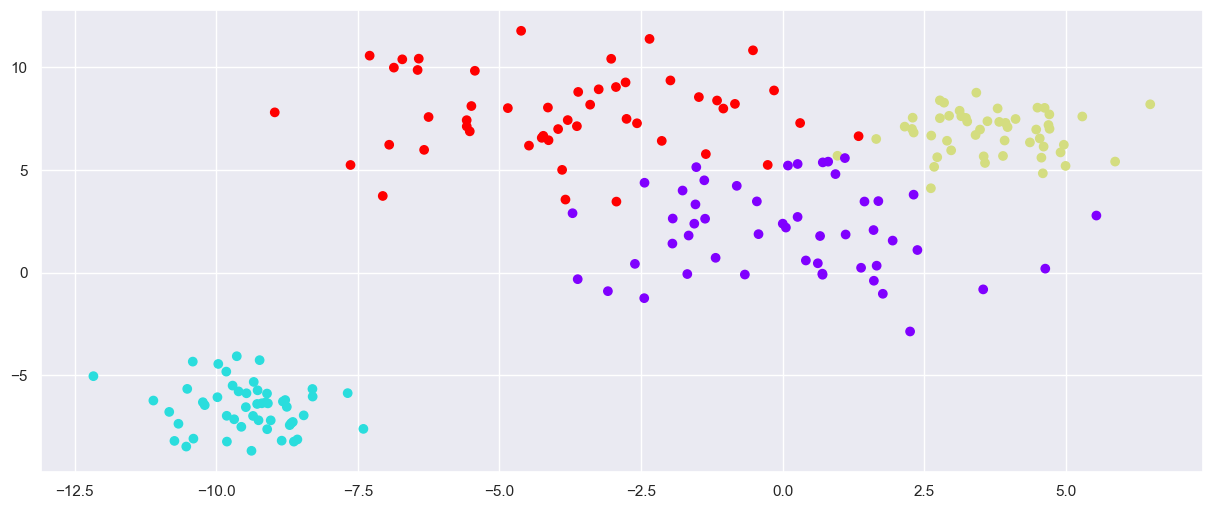

In [19]:
#### visualizar o conj de dados
fig, ax = plt.subplots(figsize=(15,6))

#### linha, colunas e cores
plt.scatter(data[0][:,0],data[0][:,1], c=data[1], cmap='rainbow') # 4 clusters

In [20]:
# ve a que classe pertence, com o modelo treinado
from sklearn.cluster import KMeans

In [21]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(data[0])

KMeans(n_clusters=4)

In [22]:
KMeans(n_clusters=4)

KMeans(n_clusters=4)

In [23]:
# mostrar todos os centroides de cada clusters, encontrou os pontos centrais
kmeans.cluster_centers_

array([[-9.45212819, -6.56470497],
       [ 3.22962915,  6.57426507],
       [-4.26532727,  8.04228496],
       [-0.31922142,  1.65750485]])

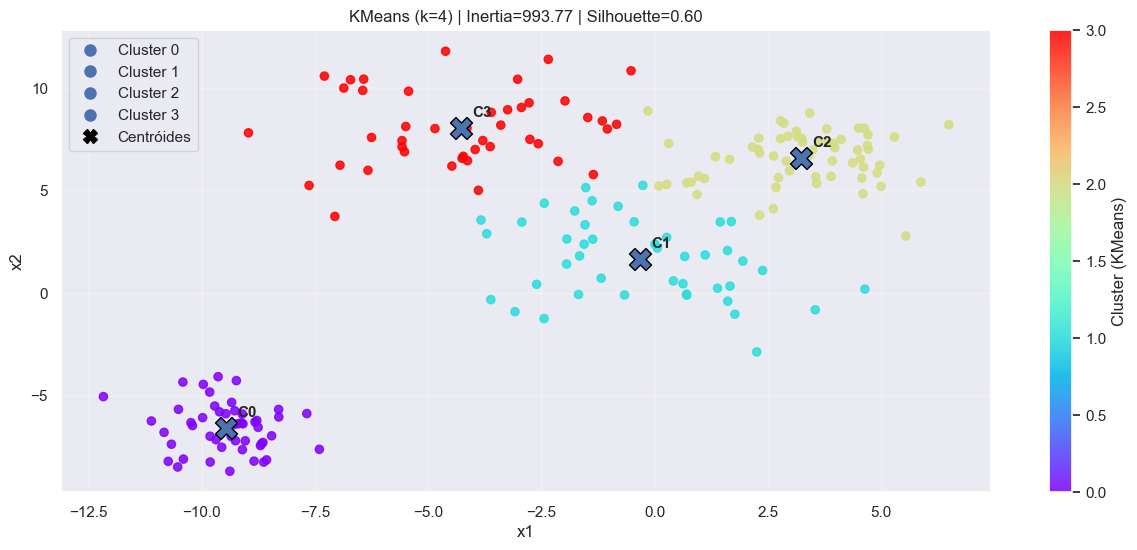

Inertia: 993.7672
Silhouette: 0.6024
Centros:
 [[-9.45212819 -6.56470497]
 [-0.31922142  1.65750485]
 [ 3.22962915  6.57426507]
 [-4.26532727  8.04228496]]


In [25]:
#### CODGI CHAT
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D

X = np.asarray(data[0])

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

inertia = kmeans.inertia_
sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan

fig, ax = plt.subplots(figsize=(15, 6))

# Pontos por cluster
sc = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="rainbow", s=35, alpha=0.85)

# Centrões
ax.scatter(
    centers[:, 0], centers[:, 1],
    marker="X", s=250, edgecolor="black", linewidth=1.0,
    label="Centróides"
)

# Anotar centróides
for i, (cx, cy) in enumerate(centers):
    ax.annotate(f"C{i}", (cx, cy), textcoords="offset points", xytext=(8, 8), fontsize=11, weight="bold")

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Cluster (KMeans)")

# ✅ Legenda manual SEM erro (Line2D)
legend_items = [
    Line2D([0], [0], marker='o', linestyle='', label=f'Cluster {i}', markersize=8)
    for i in range(k)
]
legend_items.append(Line2D([0], [0], marker='X', color='black', linestyle='', label='Centróides', markersize=10))

ax.legend(handles=legend_items, loc="best", frameon=True)

ax.set_title(f"KMeans (k={k}) | Inertia={inertia:.2f} | Silhouette={sil:.2f}")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.grid(True, alpha=0.25)

plt.show()

print(f"Inertia: {inertia:.4f}")
print(f"Silhouette: {sil:.4f}")
print("Centros:\n", centers)


In [26]:
### cada label tem seu ponto de label
kmeans.labels_

array([3, 2, 1, 2, 2, 0, 2, 1, 2, 1, 3, 1, 2, 2, 3, 1, 2, 1, 0, 3, 0, 1,
       2, 0, 3, 0, 0, 1, 2, 2, 3, 0, 2, 1, 1, 3, 0, 0, 0, 2, 0, 3, 3, 3,
       1, 2, 3, 1, 0, 2, 1, 3, 2, 1, 0, 3, 2, 1, 3, 2, 0, 2, 0, 3, 2, 1,
       0, 2, 2, 0, 2, 2, 0, 1, 0, 2, 2, 1, 3, 1, 1, 0, 2, 0, 1, 1, 1, 3,
       2, 0, 0, 0, 0, 1, 2, 0, 2, 3, 0, 2, 1, 0, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 3, 2, 3, 2, 3, 1, 3, 1, 2, 3, 1, 0, 3, 3, 3,
       1, 0, 0, 3, 2, 1, 2, 1, 0, 2, 0, 2, 3, 2, 1, 0, 3, 3, 3, 3, 1, 2,
       1, 3, 2, 2, 2, 1, 2, 1, 1, 3, 0, 3, 1, 2, 3, 1, 2, 1, 3, 2, 2, 3,
       2, 2, 0, 2, 3, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 2, 2, 3, 0, 2, 2, 2,
       0, 1], dtype=int32)

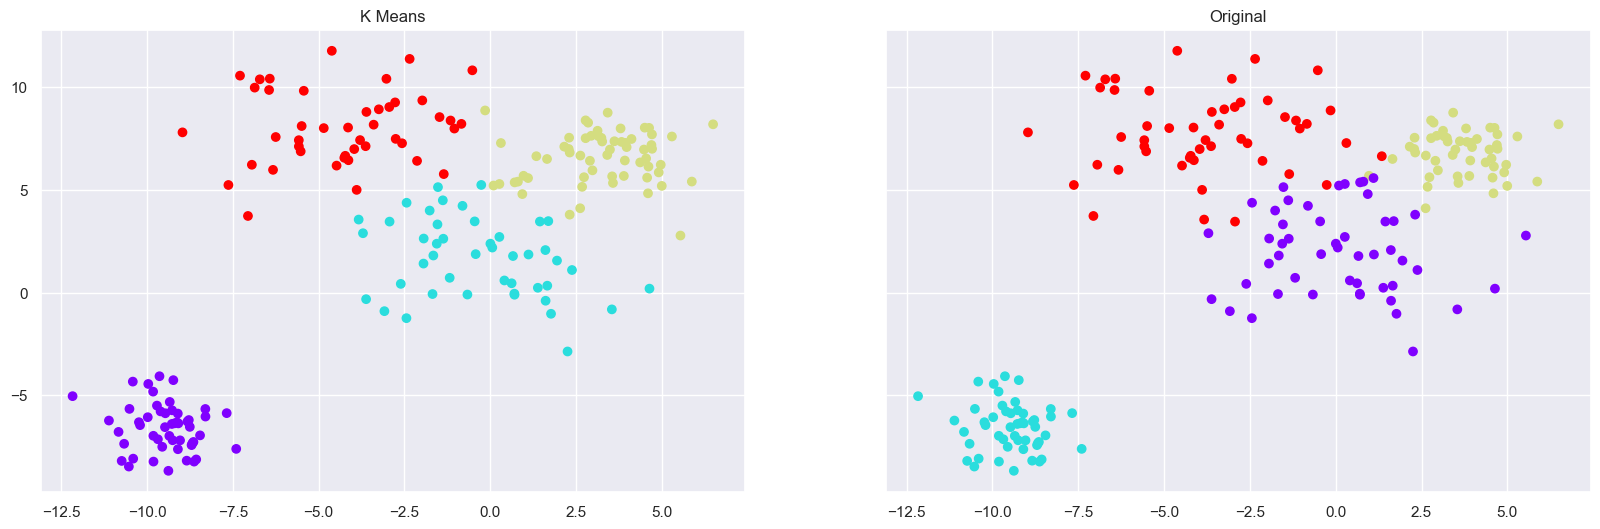

In [27]:
# criar 2 subplotes
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True,figsize=(20, 6)) # compartilha o eixo y, tamanho da figura figsize=(20, 6)
ax1.set_title('K Means')
ax1.scatter(data[0][:,0],data[0][:,1],c=kmeans.labels_,cmap='rainbow')

ax2.set_title("Original")
ax2.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

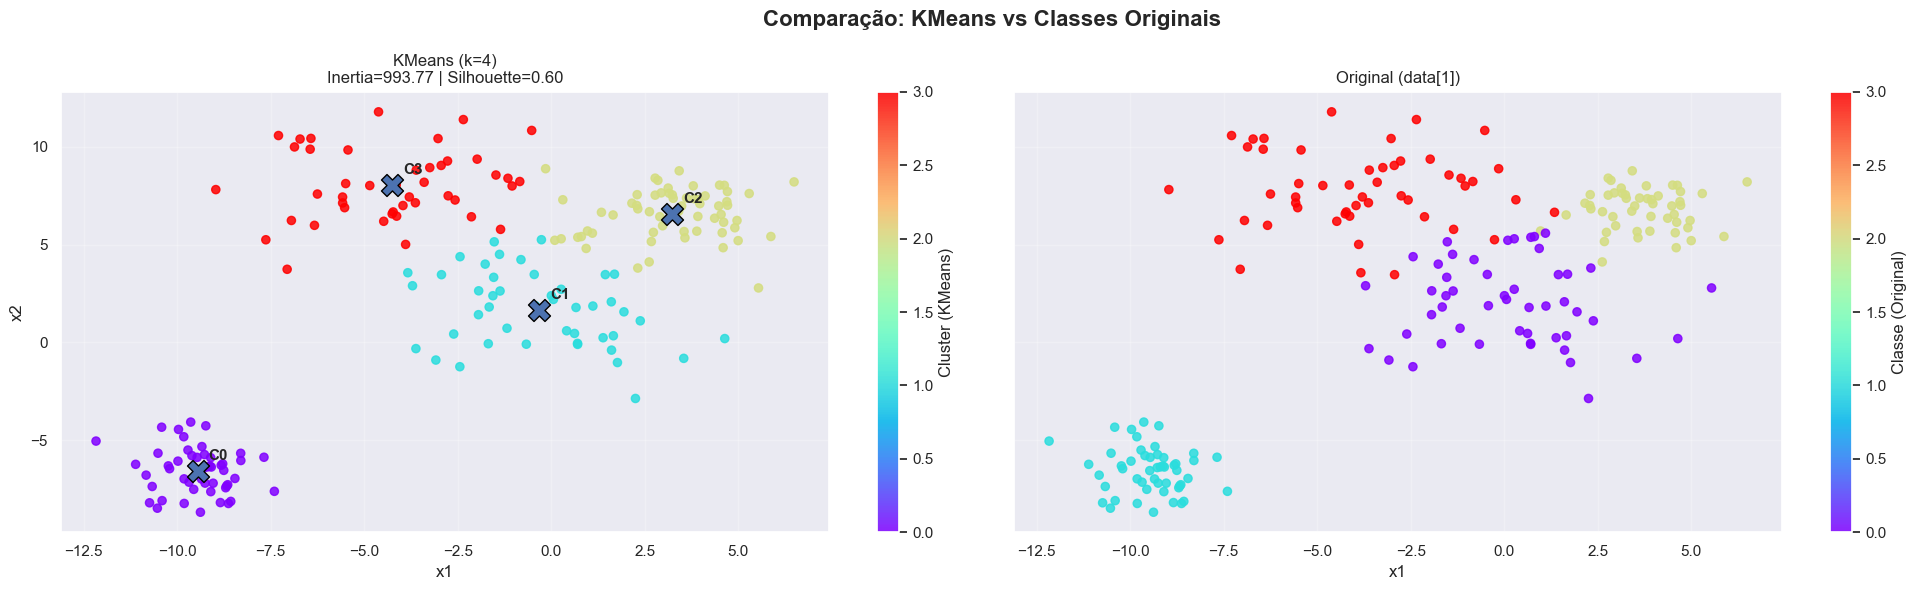

In [28]:
# versao chat = Versão melhorada (2 subplots + centróides + colorbar + métricas)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = np.asarray(data[0])
y = np.asarray(data[1])  # rótulos "originais" (se existirem)

# Treinar (se você já tiver kmeans treinado, pode pular esta parte)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

inertia = kmeans.inertia_
sil = silhouette_score(X, labels) if len(np.unique(labels)) > 1 else np.nan

# -----------------------------
# 2 gráficos lado a lado
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(20, 6))

# ---- Plot 1: KMeans ----
sc1 = ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap="rainbow", s=35, alpha=0.85)
ax1.scatter(
    centers[:, 0], centers[:, 1],
    marker="X", s=250, edgecolor="black", linewidth=1.0
)

for i, (cx, cy) in enumerate(centers):
    ax1.annotate(f"C{i}", (cx, cy), textcoords="offset points", xytext=(8, 8), fontsize=11, weight="bold")

ax1.set_title(f"KMeans (k={k})\nInertia={inertia:.2f} | Silhouette={sil:.2f}")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.grid(True, alpha=0.25)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label("Cluster (KMeans)")

# ---- Plot 2: Original ----
sc2 = ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="rainbow", s=35, alpha=0.85)
ax2.set_title("Original (data[1])")
ax2.set_xlabel("x1")
ax2.grid(True, alpha=0.25)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label("Classe (Original)")

plt.suptitle("Comparação: KMeans vs Classes Originais", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


In [29]:
# conjunto de dados de treinamento ### Problemas do K-Means


In [30]:
from sklearn.datasets import make_gaussian_quantiles

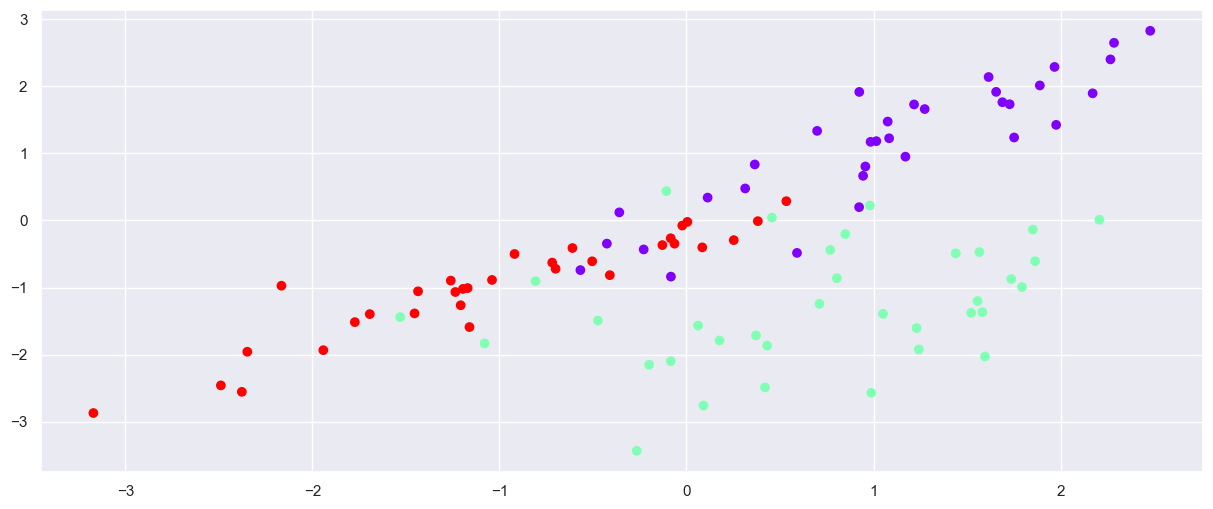

In [35]:
from sklearn.datasets import make_classification, make_gaussian_quantiles


data = make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, 
                           n_classes=3, random_state=21)

fig, ax = plt.subplots(figsize=(15, 6))
plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

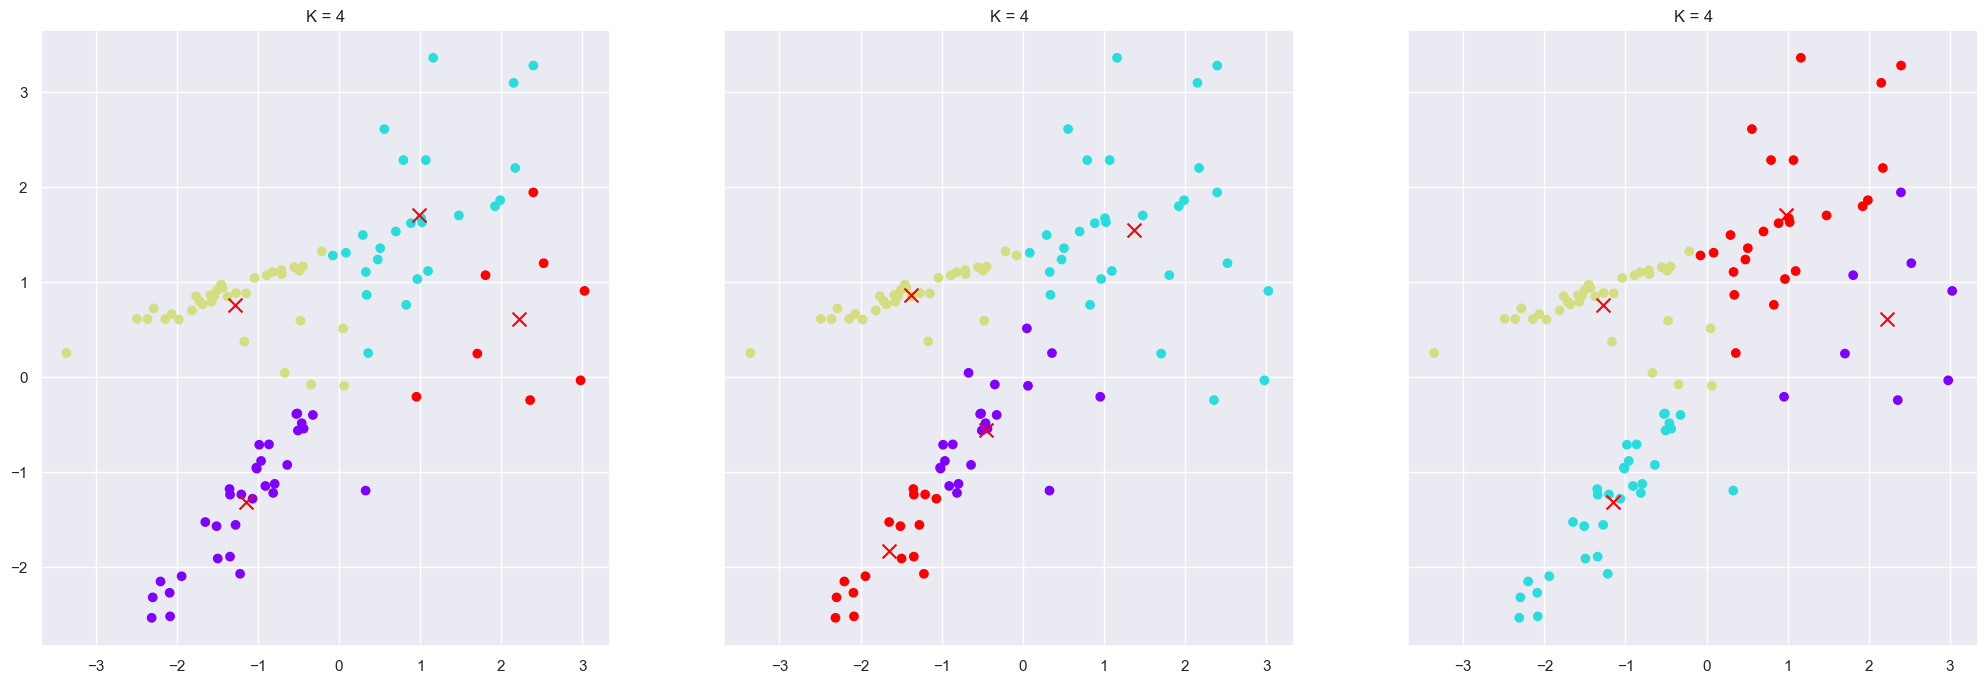

In [39]:
n = 3
f, ax = plt.subplots(1, n, sharey=True,figsize=(25, 8))

### conjunto de dados
data = make_classification(n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, 
                           n_classes=3, random_state=24)

### faz a interacao por eles e cria 3 modelos iguais
i = 0
for _ in range(n):
    ax[i].set_title('K = 4'.format(4))
    kmeans = KMeans(n_clusters=4)
    kmeans.fit(data[0])

    ax[i].scatter(data[0][:,0],data[0][:,1], c=kmeans.labels_, cmap="rainbow")
    ax[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="x", color="red", s=100)
    i += 1
    # mesmo assim o modelo nao responde da mesma forma
    # treinamos o codig e ele localizou os centroides que sao os X das imgs
    # as classes estao no mesmo ponto

In [40]:
# somatorio quadrado d a inercia
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)
kmeans.fit(data[0])

KMeans(n_clusters=4)

In [42]:
kmeans.inertia_

# somatorio quadrado d a inercia

80.26160980066837

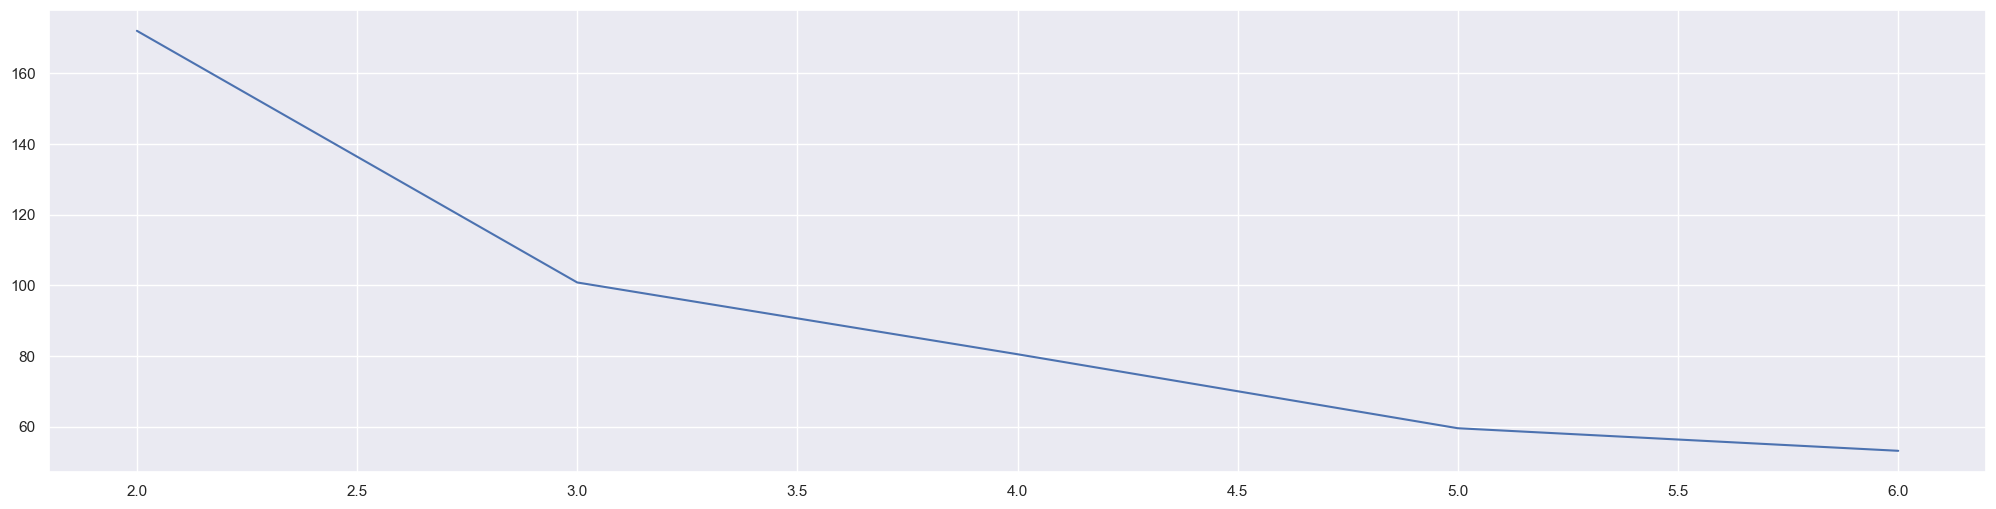

In [43]:
f, ax = plt.subplots(figsize=(25, 6))

list_inertia = [] # variavel

# testar o valor de K

list_k = []  # variavel

for k in [2, 3, 4, 5, 6]: # valores
    # treinar o moddelo novo
    kmeans = KMeans(n_clusters=k) # substitui o clusters por K
    kmeans.fit(data[0])
    
    list_inertia += [kmeans.inertia_]
    list_k += [k]
ax.plot(list_k, list_inertia) # ver o grafico com os pontos treinados
# o ponto 5.0 seria o ponto ideal para o programa


In [44]:
# ver valores 
list_k

[2, 3, 4, 5, 6]

In [45]:
list_inertia

[171.9773834353826,
 100.76724749804626,
 80.45694325326971,
 59.5199249500495,
 53.136242961588835]

# como encontrar o valor de K ideal => kmeans

O que é inércia no KMeans?

👉 Inércia é a soma das distâncias ao quadrado de cada ponto até o centróide do seu cluster.
Tradução humana:

“O quão espalhados os pontos estão dentro dos clusters.”

Inércia baixa → clusters compactos

Inércia alta → clusters espalhados

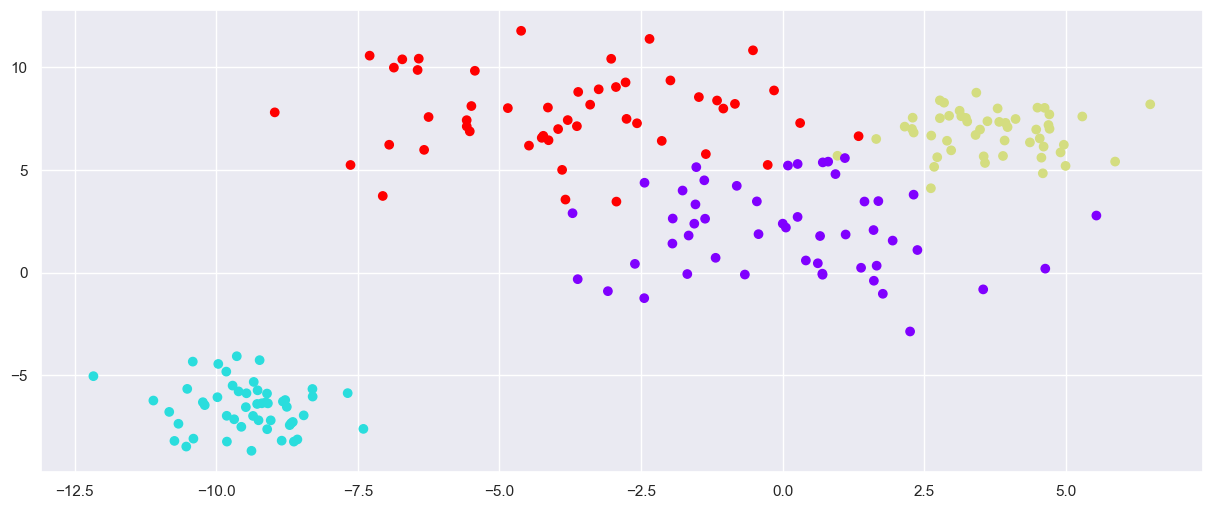

In [37]:
# funcao de make_blobs

data = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=[2, 1, 1, 2],random_state=101)
fig, ax = plt.subplots(figsize=(15, 6))
plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

# criamos um conjunt de dados

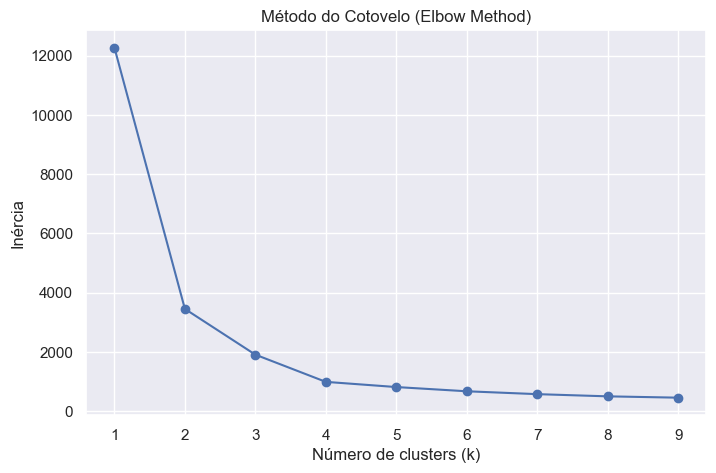

In [38]:
from sklearn.cluster import KMeans

inertias = []

Ks = range(1, 10)
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data[0])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo (Elbow Method)")
plt.grid(True)
plt.show()


Resumo final (pra guardar)

make_blobs cria dados com clusters conhecidos

Inércia mede compactação dos clusters

KMeans tenta minimizar a inércia

Método do cotovelo usa a inércia para escolher k

Inércia sozinha não basta para validar clusters

### Gaussian Mixture Models
# Modelos misturados

#### Multiplas dimensoes (interpretando modelos no PY)

In [47]:
from sklearn.datasets import make_gaussian_quantiles
# gerador de gaussian

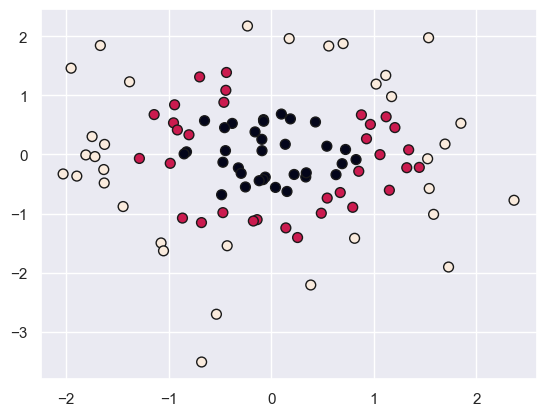

In [48]:
# parametros
X1, Y1 = make_gaussian_quantiles(n_features=2, n_classes=3) # features e classes
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=50, edgecolor="k") # rodar a funcao e passar as coordenadas

In [49]:
# ver oque o modelo acha dessas informacoes, treinar
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3)
gm.fit(X1)

# roda o modelo

GaussianMixture(n_components=3)

In [50]:
# ver o peso de cada uma das curvas
gm.weights_

array([0.34653585, 0.37408804, 0.27937612])

In [51]:
# vetor => ver o means onde ele acha onde esta centrada as informacoes
gm.means_

## x1 e x2 sao esses valores [ 0.006635  , -0.64912349]

array([[ 0.006635  , -0.64912349],
       [-0.88650577,  0.32936106],
       [ 1.11421954,  0.17512115]])

In [53]:
# ver as covariances
gm.covariances_

array([[[ 0.31477667,  0.20605413],
        [ 0.20605413,  0.97464892]],

       [[ 0.47359799,  0.06895661],
        [ 0.06895661,  0.56799801]],

       [[ 0.27032857, -0.15927704],
        [-0.15927704,  0.86737634]]])

In [54]:
gm.covariances_.shape
# representacao de matrix 2x2

(3, 2, 2)

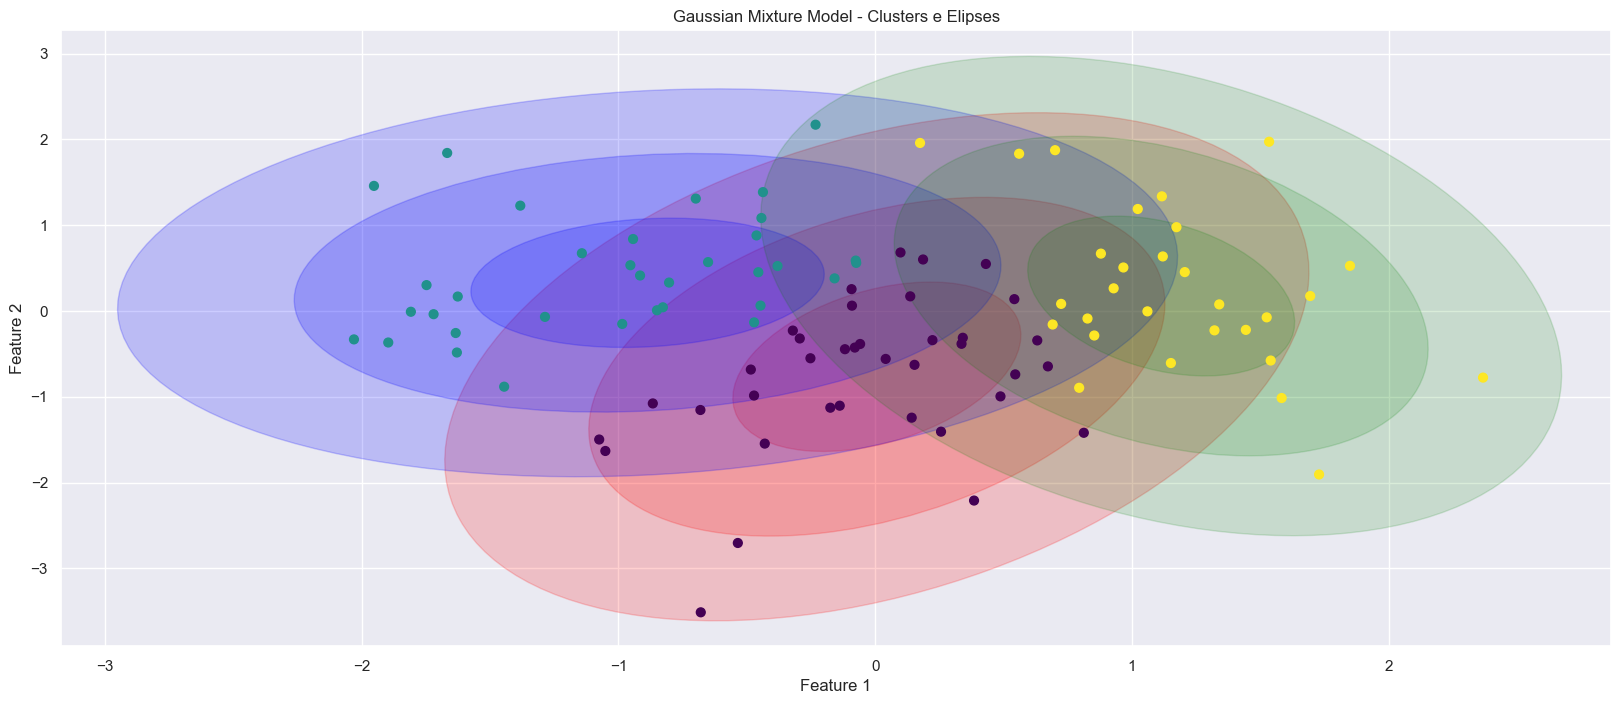

In [58]:
# plortar a informacao em grafico (mas isso nao eh normal no dia dia)
# ================================
# Imports necessários
# ================================

# NumPy: operações matemáticas e álgebra linear
import numpy as np

# Matplotlib: criação dos gráficos
import matplotlib.pyplot as plt

# Ellipse: usado para desenhar as elipses das Gaussianas
from matplotlib.patches import Ellipse


# ================================
# Função para desenhar elipses da Gaussiana
# ================================
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """
    Desenha elipses representando a distribuição Gaussiana.

    Parameters:
    - position: array-like (x, y)
        Centro da Gaussiana (mean do cluster).
    - covariance: array 2x2
        Matriz de covariância do cluster.
    - ax: matplotlib axis (opcional)
        Eixo onde a elipse será desenhada.
    - **kwargs:
        Parâmetros visuais (cor, transparência, etc.).
    """

    # Se nenhum eixo for passado, usa o eixo atual
    if ax is None:
        ax = plt.gca()

    # --------------------------------
    # Decomposição da matriz de covariância
    # --------------------------------
    # Usamos SVD para encontrar:
    # - Direção dos eixos principais
    # - Variância em cada direção
    U, s, _ = np.linalg.svd(covariance)

    # Calcula o ângulo de rotação da elipse
    # arctan2 retorna o ângulo do vetor principal
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))

    # Largura e altura da elipse (1 sigma)
    width, height = 2 * np.sqrt(s)

    # --------------------------------
    # Desenha elipses de 1, 2 e 3 sigmas
    # --------------------------------
    # Isso ajuda a visualizar a dispersão do cluster
    for nsig in range(1, 4):
        ellipse = Ellipse(
            xy=position,                  # centro da elipse
            width=nsig * width,           # escala do eixo x
            height=nsig * height,          # escala do eixo y
            angle=angle,                  # rotação da elipse
            **kwargs
        )

        # Adiciona a elipse ao gráfico
        ax.add_patch(ellipse)


# ================================
# Função para plotar GMM + dados
# ================================
def plot_gmm(gmm, X):
    """
    Plota os dados e as Gaussianas do Gaussian Mixture Model.

    Parameters:
    - gmm: objeto GaussianMixture já treinado
    - X: array NumPy (n_samples, 2)
        Dados de entrada (somente 2 dimensões).
    """

    # Cria figura e eixo do gráfico
    fig, ax = plt.subplots(figsize=(20, 8))

    # --------------------------------
    # Predição dos clusters
    # --------------------------------
    # Cada ponto recebe o cluster mais provável
    labels = gmm.predict(X)

    # Scatter plot dos dados coloridos por cluster
    ax.scatter(
        X[:, 0],                 # eixo X
        X[:, 1],                 # eixo Y
        c=labels,                # cor por cluster
        s=40,                    # tamanho dos pontos
        cmap="viridis",          # mapa de cores
        zorder=2
    )

    # --------------------------------
    # Fator de escala baseado no peso do cluster
    # --------------------------------
    # Clusters com maior peso aparecem mais "fortes"
    w_factor = 0.2 / gmm.weights_.max()

    # Lista de cores para as Gaussianas
    colors = ["red", "blue", "green"]

    # --------------------------------
    # Desenha uma elipse para cada componente do GMM
    # --------------------------------
    for pos, covar, w, c in zip(
        gmm.means_,              # centros dos clusters
        gmm.covariances_,        # covariâncias
        gmm.weights_,            # peso de cada cluster
        colors * (len(gmm.weights_) // len(colors) + 1)
    ):
        draw_ellipse(
            position=pos,
            covariance=covar,
            ax=ax,
            alpha=w * w_factor,  # transparência proporcional ao peso
            edgecolor=c,
            facecolor=c
        )

    # --------------------------------
    # Ajustes finais do gráfico
    # --------------------------------
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title("Gaussian Mixture Model - Clusters e Elipses")

    # Exibe o gráfico
    plt.show()


# ================================
# Exemplo de uso
# ================================

# gm deve ser um GaussianMixture já treinado
# X1 deve ser um array NumPy com shape (n_amostras, 2)
plot_gmm(gm, X1)


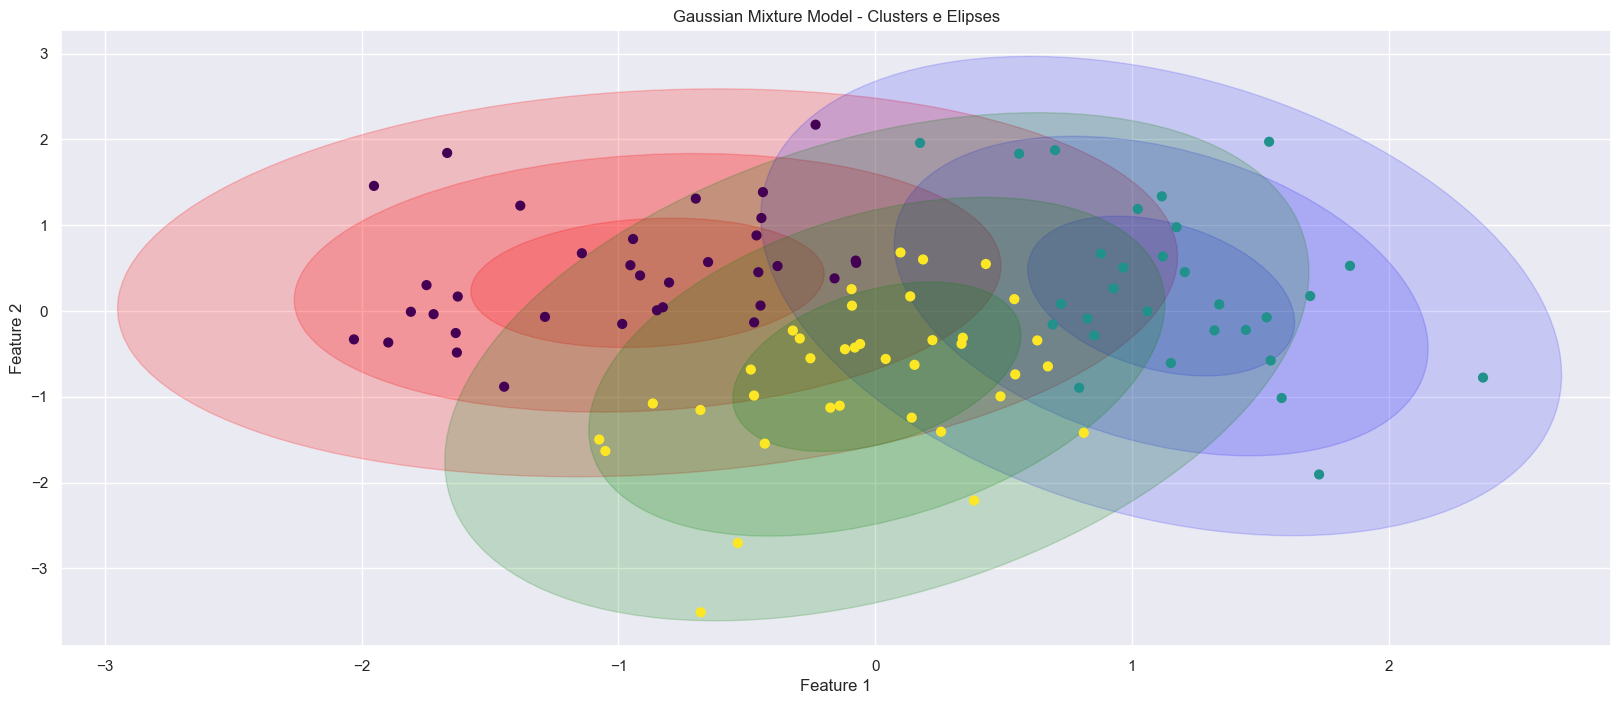

In [59]:
# ================================
# Imports necessários
# ================================

# NumPy para operações matemáticas e álgebra linear
import numpy as np

# Matplotlib para criação dos gráficos
import matplotlib.pyplot as plt

# Ellipse para desenhar as elipses das Gaussianas
from matplotlib.patches import Ellipse

# Gaussian Mixture Model do scikit-learn
from sklearn.mixture import GaussianMixture


# ================================
# Função para desenhar elipses da Gaussiana
# ================================
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """
    Desenha elipses representando a distribuição Gaussiana
    a partir da média e da matriz de covariância.
    """

    # Se nenhum eixo for passado, usa o eixo atual
    if ax is None:
        ax = plt.gca()

    # Decomposição da matriz de covariância usando SVD
    # U contém as direções principais
    # s contém as variâncias associadas a cada direção
    U, s, _ = np.linalg.svd(covariance)

    # Calcula o ângulo de rotação da elipse
    # Usa o vetor principal (primeira coluna de U)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))

    # Largura e altura da elipse para 1 desvio padrão (1 sigma)
    width, height = 2 * np.sqrt(s)

    # Desenha elipses correspondentes a 1, 2 e 3 sigmas
    for nsig in range(1, 4):
        ellipse = Ellipse(
            xy=position,              # centro da elipse (média do cluster)
            width=nsig * width,       # largura proporcional ao sigma
            height=nsig * height,     # altura proporcional ao sigma
            angle=angle,              # rotação da elipse
            **kwargs                  # parâmetros visuais (cor, alpha, etc.)
        )

        # Adiciona a elipse ao gráfico
        ax.add_patch(ellipse)


# ================================
# Função para plotar GMM + dados
# ================================
def plot_gmm(gmm, X):
    """
    Plota os dados em 2D e as Gaussianas aprendidas
    por um modelo Gaussian Mixture Model.
    """

    # Cria a figura e o eixo do gráfico
    fig, ax = plt.subplots(figsize=(20, 8))

    # Prediz o cluster mais provável para cada ponto
    labels = gmm.predict(X)

    # Plota os pontos coloridos de acordo com o cluster
    ax.scatter(
        X[:, 0],                     # valores da primeira feature
        X[:, 1],                     # valores da segunda feature
        c=labels,                    # cor baseada no cluster
        s=40,                        # tamanho dos pontos
        cmap="viridis",              # mapa de cores
        zorder=2
    )

    # Fator de escala baseado no maior peso dos clusters
    # Evita que as elipses fiquem opacas demais
    w_factor = 0.2 / gmm.weights_.max()

    # Lista de cores para as Gaussianas
    colors = ["red", "blue", "green"]

    # Itera sobre cada componente do GMM
    for pos, covar, w, c in zip(
        gmm.means_,                  # médias (centros dos clusters)
        gmm.covariances_,            # matrizes de covariância
        gmm.weights_,                # pesos de cada cluster
        colors * (len(gmm.weights_) // len(colors) + 1)
    ):
        draw_ellipse(
            position=pos,             # centro da Gaussiana
            covariance=covar,         # covariância da Gaussiana
            ax=ax,                    # eixo do gráfico
            alpha=w * w_factor,       # transparência proporcional ao peso
            edgecolor=c,              # cor da borda
            facecolor=c               # cor de preenchimento
        )

    # Ajustes finais do gráfico
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title("Gaussian Mixture Model - Clusters e Elipses")

    # Exibe o gráfico
    plt.show()


# ================================
# Treinamento do modelo
# ================================

# Cria o modelo GMM com 3 componentes (clusters)
gm = GaussianMixture(n_components=3, random_state=42)

# Ajusta o modelo aos dados X1
gm.fit(X1)


# ================================
# Visualização dos resultados
# ================================

# Plota os dados e as Gaussianas aprendidas pelo modelo
plot_gmm(gm, X1)


# Pontos importantes: 
SVD é usada para achar:

orientação da elipse

variância em cada eixo principal

1, 2 e 3 sigmas mostram bem a dispersão e sobreposição dos clusters

weights_ controla quão “forte” visualmente cada Gaussiana aparece

Esse gráfico é didático e diagnóstico, não algo de produçãoS